# 05 · CBI ranking — from episodes to a defensible investment list (IEEE v4 sample)

The final deliverable: rank bottlenecks by
**CBI score = frequency × duration × severity**, and *classify* them:

| class | meaning | action |
|---|---|---|
| `active_bottleneck` | local cause: demand > capacity here | fix HERE (ramp meter, aux lane) |
| `queued_passive` | victim of a downstream active bottleneck | fixing here does nothing |
| `spillback_source` | queue originates here and floods upstream | fix here, benefit propagates |
| `incident_related` | statistical outlier day (z-score event) | dispatch/incident mgmt, not construction |
| `isolated_uncertain` | not enough evidence | more data first |

Data: the in-repo IEEE TrafficFlowBench **v4 sample** (I-405 N, 3 days).
Two format lessons baked in: v4 speeds are **km/h** (convert!), and
`is_observed == 0` cells are imputation — never calibrate on them.

In [1]:
%matplotlib inline
# If cbi-plus is pip-installed this import just works; on a raw repo
# checkout we add the repo root to the path instead.
try:
    import cbi_pipeline
except ImportError:
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent))
from cbi_pipeline import api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["figure.dpi"] = 90
print("cbi-plus", api.version())

cbi-plus 2.2.0


In [2]:
# one line — the loader converts km/h -> mph, total -> per-lane flow
# (effective lanes derived from the data), and drops imputed cells
df = api.load_ieee_v4("../benchmarks/ieee_v4_samples/I405N/train_detector_states_3days.csv",
                      corridor="I405N")
print(f"{df['sensor_uid'].nunique()} detectors, {df['datetime'].dt.date.nunique()} days, {len(df):,} rows")

65 detectors, 3 days, 56,160 rows


Three traps the loader handles for you (they cost a simulated competition
team hours): v4 speeds are km/h; v4 flow is a TOTAL across lanes while the
package contract is per-lane; and on south/westbound corridors milepost
DEcreases downstream — pass `chain_csv=".../detector_chain_fd.csv"` there
so ordering comes from the chain. The I-5 samples are `.csv.gz` — pandas
reads them directly.

In [3]:
out = api.diagnose(df)
rank = out["ranking"]
rank[["sensor_uid", "period", "freq_episodes_per_day", "median_P_hours",
      "median_v_t2_mph", "CBI_score", "bottleneck_class"]].head(10)

   [stage2] detector: packaged detector (NaN-gap guard + 2-bin persistence active)


   [stage2] boundary-merge: stitched 49 MD+PM episode pairs into MDPM (constituents kept, de-validated)


C:\Users\xzhou\AppData\Local\Temp\ipykernel_34520\2131180264.py:1: UserWarning: 2/65 FD fits fail physics checks (r_squared <= 0, capacity outside 1200-2600 vphpl, or v_f outside 40-90 mph) — see fd_summary['fit_ok']. Common causes: total instead of per-lane flow, km/h speeds, or a detector that never reaches congestion.
  out = api.diagnose(df)


   [stage6] CBI ranking: 27 sensor-periods; top-5:
      #1  1213650                MDPM  score=5.2058   spillback_source
      #2  1209243                MDPM  score=5.1044   queued_passive
      #3  1201671                MDPM  score=2.1136   spillback_source
      #4  1201606                MDPM  score=1.9064   queued_passive
      #5  1201959                MDPM  score=1.6078   queued_passive


,sensor_uid,period,freq_episodes_per_day,median_P_hours,median_v_t2_mph,CBI_score,bottleneck_class
0,1213650,MDPM,1.000,6.33,8.9,5.2058,spillback_source
1,1209243,MDPM,1.000,6.33,9.7,5.1044,queued_passive
2,1201671,MDPM,1.000,4.92,28.5,2.1136,spillback_source
3,1201606,MDPM,0.667,4.58,18.8,1.9064,queued_passive
4,1201959,MDPM,1.000,4.17,30.7,1.6078,queued_passive
5,1222784,MDPM,0.667,4.04,20.9,1.5706,queued_passive
6,1201787,MDPM,0.667,4.96,30.2,1.3086,queued_passive
7,1201637,MDPM,1.000,4.33,36.6,1.1607,queued_passive
8,1201751,MDPM,0.333,5.00,24.6,0.8465,queued_passive
9,1201823,MDPM,0.333,5.00,24.9,0.8365,queued_passive


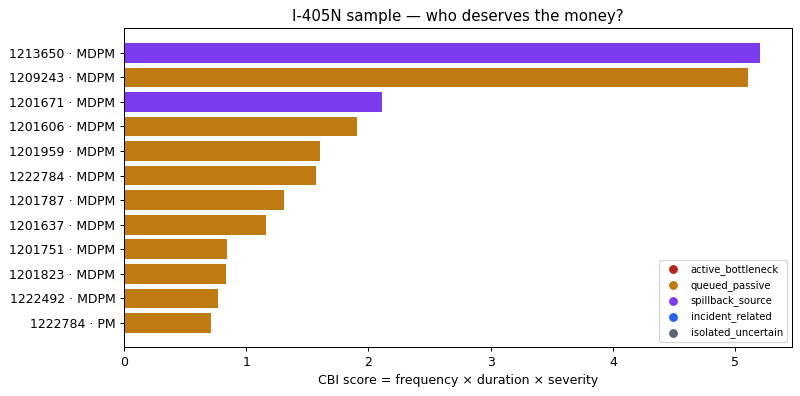

In [4]:
top = rank.head(12).iloc[::-1]
cls_color = {"active_bottleneck": "#b3261e", "queued_passive": "#c07a12",
             "spillback_source": "#7c3aed", "incident_related": "#2563eb",
             "isolated_uncertain": "#5a6472"}
plt.figure(figsize=(9, 4.5))
labels = top["sensor_uid"].str[-7:] + " · " + top["period"]
plt.barh(labels, top["CBI_score"],
         color=[cls_color.get(c, "#5a6472") for c in top["bottleneck_class"]])
for cls, col in cls_color.items():
    plt.scatter([], [], color=col, label=cls)
plt.legend(fontsize=8, loc="lower right")
plt.xlabel("CBI score = frequency × duration × severity")
plt.title("I-405N sample — who deserves the money?")
plt.tight_layout(); plt.show()

## The engineering argument

Two locations can look identically red on a speed map, yet one is an
`active_bottleneck` (build here) and one is `queued_passive` (building here
wastes money). The classification comes from **wave direction and topology**
— physics, not thresholds. That is the difference between a dashboard and a
diagnosis.

### Where to go next
- Swap in `I405S`, `I5N`, or `I5S` from `../benchmarks/ieee_v4_samples/` — one line.
- The AI arena (`cbi_pipeline.ai_arena`) reconstructs masked detector data
  with 5 model families; see [engine comparison](../benchmarks/engine_comparison/index.html).
- Full teaching ladder: [docs/teaching/README.md](../docs/teaching/README.md).